In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data_clean.csv')
df.head()

,ATM_POS,TBM,CSC
0,-0.852354,-0.294938,0.143935
1,-0.333078,-0.244334,0.939343
2,0.918067,0.593787,2.349496
3,-0.741847,-0.210507,-0.521592
4,-0.499703,-0.492714,-0.367629


In [5]:
var = ['ATM_POS',"TBM","CSC"]
skew_var = {}

In [8]:
for i in var:
    skew_var[i] = abs(df[i].skew())
    skew = pd.Series(skew_var).sort_values(ascending=False)
print(skew)

TBM        51.881233
CSC         6.093417
ATM_POS     2.097633
dtype: float64


In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
result = kmeans.fit(df)
result


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
# 对分类结果进行解读
model_data_l = df.join(pd.DataFrame(result.labels_)) 
                            # .labels_ 表示这一个数据点属于什么类
model_data_l = model_data_l.rename(columns={0: "clustor"})
model_data_l.sample(10)

,ATM_POS,TBM,CSC,clustor
79576,-0.880690,0.785719,-0.497296,1
42863,-0.759010,0.217289,0.580066,1
83553,-0.271874,-0.449509,0.711148,1
33307,-0.885286,0.299475,0.070995,1
89062,2.926480,0.224803,4.328726,0
49615,-0.885322,-0.352910,-0.506254,1
31833,-0.561151,0.331329,-0.289081,1
13907,-0.092090,2.489783,-0.402001,1
48196,-0.886041,-0.529594,-0.507644,1
3300,-0.885921,-0.500147,-0.507413,1


k-means聚类的第二种方式
进行变量分布的正态转换--用于客户细分
Quantile → 正态化 → KMeans

优点：

cluster 更均衡
更适合客户细分
距离结构稳定

缺点：

丢失“真实数值意义”
不能解释绝对大小

In [ ]:
import numpy as np
from sklearn import preprocessing
quantile_transformer = \
    preprocessing.QuantileTransformer(output_distribution='normal', 
                                      random_state=0) 
# 正态转QuantileTransformer 是把每个变量的“排名结构”映射到正态分布，用于消除偏态对 K-Means 距离计算的干扰，使客户细分更稳定。

In [16]:
df_trans = quantile_transformer.fit_transform(df)
df_trans = pd.DataFrame(df_trans)  
 # 因为 .fit_transform 转换出来的数据类型为 Series，
    ## 所以用 pandas 给 DataFrame 化一下

df_trans = df_trans.rename(columns={0: "ATM_POS", 1: "TBM", 2: "CSC"})
df_trans.head()

,ATM_POS,TBM,CSC
0,-0.500074,-0.263286,0.771350
1,0.095454,-0.142501,1.309555
2,0.933541,1.175246,1.836506
3,-0.330865,-0.079463,-1.776468
4,-0.071296,-0.897128,-0.067301


In [18]:
var = ["ATM_POS","TBM","CSC"]
skew_var = {}
for i in var:
    skew_var[i] = abs(df_trans[i].skew())
    skew = pd.Series(skew_var).sort_values(ascending=False)
skew  

TBM        0.012075
ATM_POS    0.011758
CSC        0.007694
dtype: float64

In [27]:
kmeans = KMeans(n_clusters=4)  # 这次聚成 4 类
result = kmeans.fit(df_trans)

model_data_l = df_trans.join(pd.DataFrame(result.labels_))
model_data_l = model_data_l.rename(columns={0: "clustor"})
model_data_l.head()

,ATM_POS,TBM,CSC,clustor
0,-0.500074,-0.263286,0.771350,0
1,0.095454,-0.142501,1.309555,1
2,0.933541,1.175246,1.836506,1
3,-0.330865,-0.079463,-1.776468,2
4,-0.071296,-0.897128,-0.067301,2


KMeans 划分的 4 类客户中，每一类分别占整体客户的多少比例。

<Axes: ylabel='count'>

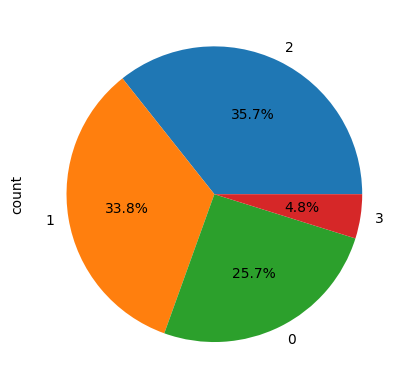

In [28]:
model_data_l["clustor"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)